# 08A: DIJKSTRA HOTTEST ROUTE (HYBRID PATCHWORK APPROACH)

This notebook finds the HOTTEST pedestrian route using Dijkstra's algorithm with a hybrid cost surface. The hybrid approach merges GSV-based predictions (high fidelity in sampled wards) with raster-only predictions (full coverage). Areas with GSV data use the more accurate GSV model predictions.

## MODULE SETUP

In [1]:
# Mount Google Drive.
from google.colab import drive
drive.mount("/content/drive")

Mounted at /content/drive


In [2]:
import os

# Set working directory to project folder.
BASE_DIR = "/content/drive/MyDrive/Colab Notebooks/hot_hem"
os.chdir(BASE_DIR)

print(f"Working directory: {BASE_DIR}")

Working directory: /content/drive/MyDrive/Colab Notebooks/hot_hem


## IMPORT SETUP

In [4]:
! pip install osmnx

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 101.5/101.5 kB 3.4 MB/s eta 0:00:00


In [5]:
from pathlib import Path
import pickle
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.lines import Line2D
import rasterio
from rasterio.transform import from_bounds
from rasterio.crs import CRS
from scipy.interpolate import griddata
import networkx as nx
import osmnx as ox
from shapely.geometry import Point, LineString, box

## PATH CONFIGURATION

In [6]:
# Input paths.
BOUNDARY_FILE = Path("data/inputs/boundaries/aoi_wards.geojson")
NETWORK_FILE = Path("data/processing/network/network.graphml")
FULL_MODEL_FILE = Path("models/xgboost_full_model.pkl")
DEPLOYMENT_MODEL_FILE = Path("models/xgboost_deployment_model.pkl")
GSV_FEATURES_FILE = Path("data/outputs/features/gsv_with_raster_features.csv")
NETWORK_FEATURES_FILE = Path("data/outputs/features/network_nodes_with_raster_features.csv")

# Output paths.
OUT_DIR = Path("data/outputs/routing")
OUT_DIR.mkdir(parents = True, exist_ok = True)

PRED_RASTER_ONLY = OUT_DIR / "pred_raster_only.tif"
PRED_GSV = OUT_DIR / "pred_gsv.tif"
HYBRID_RASTER = OUT_DIR / "hybrid_cost_surface.tif"
HOTTEST_ROUTE = OUT_DIR / "hottest_route_hybrid.geojson"

print("PATH CONFIGURATION")
print(f"Boundary file: {BOUNDARY_FILE}")
print(f"Network file: {NETWORK_FILE}")
print(f"Output directory: {OUT_DIR}")

PATH CONFIGURATION
Boundary file: data/inputs/boundaries/aoi_wards.geojson
Network file: data/processing/network/network.graphml
Output directory: data/outputs/routing


## LOAD STUDY AREA BOUNDARIES

In [7]:
# Load ward boundaries.
gdf_wards = gpd.read_file(BOUNDARY_FILE)

print(f"Loaded {len(gdf_wards)} ward boundaries.")
print(f"Columns: {list(gdf_wards.columns)}")
print(f"CRS: {gdf_wards.crs}")
gdf_wards.head()

Loaded 37 ward boundaries.
Columns: ['OBJECTID', 'COUNTRY', 'ENGNAME', 'NAME_1', 'ENGNAME_1', 'NAME_2', 'ENGNAME_2', 'NAME_3', 'ENGNAME_3', 'TYPE_3', 'ENGTYPE_3', 'Shape_Length', 'Shape_Area', 'geometry']
CRS: EPSG:4326


,OBJECTID,COUNTRY,ENGNAME,NAME_1,ENGNAME_1,NAME_2,ENGNAME_2,NAME_3,ENGNAME_3,TYPE_3,ENGTYPE_3,Shape_Length,Shape_Area,geometry
0,4644,Việt Nam,Vietnam,Hồ Chí Minh,Ho Chi Minh,Quận 1,District 1,Bến Nghé,Ben Nghe,Phường,Ward,0.064065,0.000204,"POLYGON ((106.70944 10.78751, 106.70921 10.787..."
1,4645,Việt Nam,Vietnam,Hồ Chí Minh,Ho Chi Minh,Quận 1,District 1,Bến Thành,Ben Thanh,Phường,Ward,0.038229,0.000077,"POLYGON ((106.69501 10.77958, 106.68721 10.771..."
2,4646,Việt Nam,Vietnam,Hồ Chí Minh,Ho Chi Minh,Quận 1,District 1,Cầukho,Caukho,Phường,Ward,0.022276,0.000028,"POLYGON ((106.68813 10.75439, 106.68875 10.754..."
3,4647,Việt Nam,Vietnam,Hồ Chí Minh,Ho Chi Minh,Quận 1,District 1,Cầu Ông Lãnh,Cau Ong Lanh,Phường,Ward,0.017988,0.000018,"POLYGON ((106.69755 10.7624, 106.69792 10.7629..."
4,4648,Việt Nam,Vietnam,Hồ Chí Minh,Ho Chi Minh,Quận 1,District 1,Cô Giang,Co Giang,Phường,Ward,0.023104,0.000030,"POLYGON ((106.69269 10.75825, 106.69449 10.759..."


In [8]:
# Define GSV-sampled wards (high fidelity areas).
# These are wards where GSV imagery was collected.
GSV_WARDS = [
    "Ben Thanh",
    "Co Giang",
    "Thao Dien",
    "An Khanh",
    "Ward 5",
    "Ward 6"
]

# Identify ward column name.
ward_col = None
for col in ["ward", "Ward", "name", "NAME", "ten_phuong"]:
    if col in gdf_wards.columns:
        ward_col = col
        break

if ward_col:
    print(f"Ward column: {ward_col}")
    print(f"Available wards: {gdf_wards[ward_col].unique()}")
else:
    print("Ward column not found. Using all boundaries.")

Ward column not found. Using all boundaries.


In [9]:
# Get study area bounds.
total_bounds = gdf_wards.total_bounds
minx, miny, maxx, maxy = total_bounds

print("STUDY AREA BOUNDS")
print(f"Min X (lon): {minx:.6f}")
print(f"Max X (lon): {maxx:.6f}")
print(f"Min Y (lat): {miny:.6f}")
print(f"Max Y (lat): {maxy:.6f}")

STUDY AREA BOUNDS
Min X (lon): 106.594556
Max X (lon): 106.810093
Min Y (lat): 10.689854
Max Y (lat): 10.819768


## VISUALIZE STUDY AREA

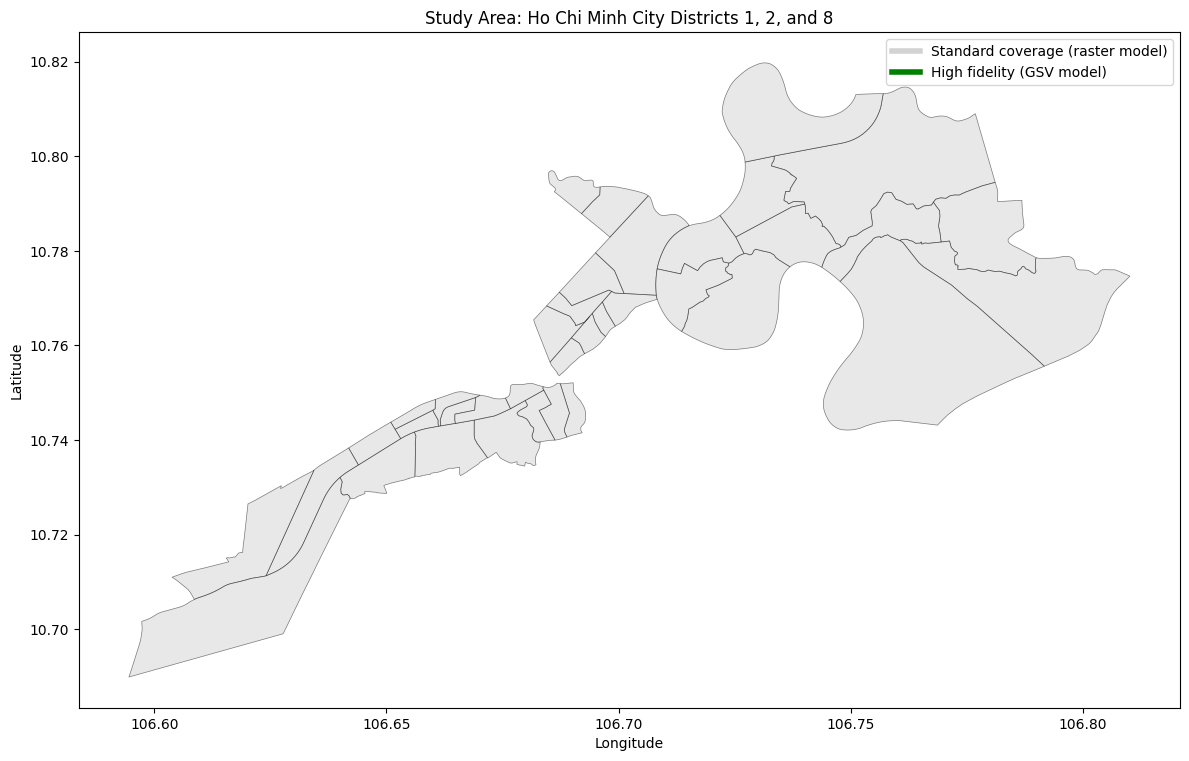

In [10]:
# Create study area visualization.
fig, ax = plt.subplots(1, 1, figsize = (12, 10))

# Plot all wards.
gdf_wards.plot(
    ax = ax,
    facecolor = "lightgray",
    edgecolor = "black",
    linewidth = 0.5,
    alpha = 0.5
)

# Highlight GSV-sampled wards if ward column exists.
if ward_col:
    gsv_mask = gdf_wards[ward_col].isin(GSV_WARDS)
    gdf_wards[gsv_mask].plot(
        ax = ax,
        facecolor = "green",
        edgecolor = "darkgreen",
        linewidth = 1,
        alpha = 0.4,
        label = "GSV-sampled wards"
    )

# Add ward labels.
if ward_col:
    for idx, row in gdf_wards.iterrows():
        centroid = row.geometry.centroid
        ax.annotate(
            row[ward_col],
            xy = (centroid.x, centroid.y),
            ha = "center",
            fontsize = 6,
            alpha = 0.7
        )

ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.set_title("Study Area: Ho Chi Minh City Districts 1, 2, and 8")

# Add legend.
legend_elements = [
    Line2D([0], [0], color = "lightgray", lw = 4, label = "Standard coverage (raster model)"),
    Line2D([0], [0], color = "green", lw = 4, label = "High fidelity (GSV model)"),
]
ax.legend(handles = legend_elements, loc = "upper right")

plt.tight_layout()
plt.show()

## LOAD TRAINED MODELS

In [11]:
# Load full model (GSV + raster features).
with open(FULL_MODEL_FILE, "rb") as f:
    full_model_data = pickle.load(f)

model_full = full_model_data["model"]
features_full = full_model_data["features"]

print("FULL MODEL (GSV + RASTER)")
print(f"Number of features: {len(features_full)}")
print(f"CV R2: {full_model_data.get('cv_r2', 'N/A')}")

FULL MODEL (GSV + RASTER)
Number of features: 24
CV R2: 0.8366575406894553


In [12]:
# Load deployment model (raster-only features).
with open(DEPLOYMENT_MODEL_FILE, "rb") as f:
    deploy_model_data = pickle.load(f)

model_deploy = deploy_model_data["model"]
features_deploy = deploy_model_data["features"]

print("DEPLOYMENT MODEL (RASTER ONLY)")
print(f"Number of features: {len(features_deploy)}")
print(f"CV R2: {deploy_model_data.get('cv_r2', 'N/A')}")
print(f"Features: {features_deploy}")

DEPLOYMENT MODEL (RASTER ONLY)
Number of features: 11
CV R2: 0.7960687708827403
Features: ['ndvi', 'emissivity', 'palsar_hh_db', 'palsar_hv_db', 'palsar_hv_hh_ratio', 'palsar_glcm_contrast', 'palsar_glcm_homogeneity', 'palsar_glcm_energy', 'elevation_m', 'sky_view_factor', 'landcover_class']


## LOAD FEATURE DATA

In [13]:
# Load GSV features for high-fidelity predictions.
df_gsv = pd.read_csv(GSV_FEATURES_FILE)

print(f"Loaded {len(df_gsv)} GSV sample points.")
print(f"Columns: {list(df_gsv.columns)[:10]}")
df_gsv.head()

Loaded 22878 GSV sample points.
Columns: ['uid', 'lat', 'lon', 'heading', 'district', 'ward', 'pct_other', 'pct_vegetation', 'pct_sky', 'pct_building']


,uid,lat,lon,heading,district,ward,pct_other,pct_vegetation,pct_sky,pct_building,...,emissivity,palsar_hh_db,palsar_hv_db,palsar_hv_hh_ratio,palsar_glcm_contrast,palsar_glcm_homogeneity,palsar_glcm_energy,elevation_m,sky_view_factor,landcover_class
0,2964,10.780083,106.699229,42.511501,District 1,Ben Thanh,0.882522,0.005999,0.000005,0.004031,...,2.7733,-1.812519,-6.715048,3.704816,2468.15,0.019243,0.158114,16.0,0.982801,2.0
1,2965,10.780415,106.699539,42.511501,District 1,Ben Thanh,0.743867,0.042512,0.000090,0.002720,...,2.7743,-4.105413,-7.038041,1.714332,1629.90,0.018135,0.158114,17.0,0.991037,2.0
2,2966,10.780747,106.699849,42.511501,District 1,Ben Thanh,0.841379,0.005420,0.000000,0.003713,...,2.7700,0.244117,-8.934172,-36.597968,4893.60,0.006264,0.158114,20.0,0.999020,2.0
3,2967,10.780083,106.699229,133.624199,District 1,Ben Thanh,0.894475,0.006035,0.000115,0.003193,...,2.7733,-1.812519,-6.715048,3.704816,2468.15,0.019243,0.158114,16.0,0.982801,2.0
4,2968,10.779772,106.699561,133.624199,District 1,Ben Thanh,0.910073,0.000784,0.000000,0.004768,...,2.7786,-8.977279,-14.781083,1.646499,5323.70,0.010631,0.158114,16.0,0.982814,2.0


In [14]:
# Load network node features for raster-only predictions.
df_network = pd.read_csv(NETWORK_FEATURES_FILE)

print(f"Loaded {len(df_network)} network nodes.")
print(f"Columns: {list(df_network.columns)[:10]}")
df_network.head()

Loaded 28437 network nodes.
Columns: ['osmid', 'y', 'x', 'street_count', 'highway', 'ref', 'railway', 'geometry', 'lon', 'lat']


,osmid,y,x,street_count,highway,ref,railway,geometry,lon,lat,...,emissivity,palsar_hh_db,palsar_hv_db,palsar_hv_hh_ratio,palsar_glcm_contrast,palsar_glcm_homogeneity,palsar_glcm_energy,elevation_m,sky_view_factor,landcover_class
0,366367367,10.813901,106.732449,1,NaN,NaN,NaN,POINT (106.7324492 10.8139013),106.732449,10.813901,...,2.7385,-6.660599,-10.774033,1.617577,6199.80,0.031244,0.158114,10.0,0.999971,2.0
1,366368182,10.742144,106.670913,3,NaN,NaN,NaN,POINT (106.6709134 10.7421444),106.670913,10.742144,...,2.6601,2.644283,-11.333757,-4.286137,3650.35,0.008234,0.165831,9.0,0.998736,2.0
2,366368194,10.790241,106.709544,3,NaN,NaN,NaN,POINT (106.7095438 10.7902412),106.709544,10.790241,...,2.7238,5.584384,-0.062562,-0.011203,2781.00,0.007803,0.158114,7.0,0.993674,2.0
3,366368313,10.754628,106.684140,4,NaN,NaN,NaN,POINT (106.6841396 10.7546276),106.684140,10.754628,...,2.7826,3.691487,-10.945781,-2.965141,3170.60,0.107993,0.165831,12.0,0.999859,2.0
4,366368540,10.742907,106.672759,4,NaN,NaN,NaN,POINT (106.6727592 10.742907),106.672759,10.742907,...,2.6605,7.113308,-10.508171,-1.477255,4261.00,0.003137,0.158114,6.0,0.990122,2.0


## GENERATE PREDICTIONS

In [15]:
# Generate raster-only predictions for all network nodes.
print("Generating raster-only predictions for entire study area.")

# Extract features for deployment model.
X_deploy = df_network[features_deploy].copy()

# Predict LST using raster-only model.
df_network["pred_raster_only"] = model_deploy.predict(X_deploy)

print(f"Raster-only predictions: min = {df_network['pred_raster_only'].min():.2f}, max = {df_network['pred_raster_only'].max():.2f}")

Generating raster-only predictions for entire study area.
Raster-only predictions: min = 35.51, max = 46.36


In [16]:
# Generate GSV-based predictions for GSV sample points.
print("Generating GSV-based predictions for sampled wards.")

# Check which features are available.
available_features_full = [f for f in features_full if f in df_gsv.columns]
print(f"Available features: {len(available_features_full)} / {len(features_full)}")

# If not all features available, use deployment model for GSV points too.
if len(available_features_full) < len(features_full):
    print("Using deployment model features for GSV predictions.")
    X_gsv = df_gsv[features_deploy].copy()
    df_gsv["pred_gsv"] = model_deploy.predict(X_gsv)
else:
    X_gsv = df_gsv[features_full].copy()
    df_gsv["pred_gsv"] = model_full.predict(X_gsv)

print(f"GSV predictions: min = {df_gsv['pred_gsv'].min():.2f}, max = {df_gsv['pred_gsv'].max():.2f}")

Generating GSV-based predictions for sampled wards.
Available features: 17 / 24
Using deployment model features for GSV predictions.
GSV predictions: min = 35.08, max = 46.06


## CREATE PREDICTION RASTERS

In [17]:
# Define raster parameters.
RESOLUTION = 0.0001  # Approximately 10 meters at equator.
BUFFER = 0.001  # Small buffer around study area.

# Calculate raster dimensions.
raster_minx = minx - BUFFER
raster_maxx = maxx + BUFFER
raster_miny = miny - BUFFER
raster_maxy = maxy + BUFFER

width = int((raster_maxx - raster_minx) / RESOLUTION)
height = int((raster_maxy - raster_miny) / RESOLUTION)

print("RASTER PARAMETERS")
print(f"Resolution: {RESOLUTION} degrees")
print(f"Width: {width} pixels")
print(f"Height: {height} pixels")

# Create transform.
transform = from_bounds(raster_minx, raster_miny, raster_maxx, raster_maxy, width, height)

RASTER PARAMETERS
Resolution: 0.0001 degrees
Width: 2175 pixels
Height: 1319 pixels


In [18]:
# Create coordinate grid.
x_coords = np.linspace(raster_minx, raster_maxx, width)
y_coords = np.linspace(raster_maxy, raster_miny, height)  # Reversed for image coordinates.
xx, yy = np.meshgrid(x_coords, y_coords)

print(f"Grid shape: {xx.shape}")

Grid shape: (1319, 2175)


In [19]:
# Interpolate raster-only predictions to grid.
print("Interpolating raster-only predictions to grid.")

# Get coordinates and values.
points_deploy = df_network[["lon", "lat"]].values
values_deploy = df_network["pred_raster_only"].values

# Remove NaN values.
valid_mask = ~np.isnan(values_deploy)
points_deploy = points_deploy[valid_mask]
values_deploy = values_deploy[valid_mask]

print(f"Valid points for interpolation: {len(points_deploy)}")

# Interpolate to grid.
grid_deploy = griddata(
    points_deploy,
    values_deploy,
    (xx, yy),
    method = "linear",
    fill_value = np.nan
)

# Fill remaining NaN with nearest neighbor.
nan_mask = np.isnan(grid_deploy)
if nan_mask.any():
    grid_deploy_nearest = griddata(
        points_deploy,
        values_deploy,
        (xx, yy),
        method = "nearest"
    )
    grid_deploy[nan_mask] = grid_deploy_nearest[nan_mask]

print(f"Raster-only grid: min = {np.nanmin(grid_deploy):.2f}, max = {np.nanmax(grid_deploy):.2f}")

Interpolating raster-only predictions to grid.
Valid points for interpolation: 28437
Raster-only grid: min = 35.87, max = 46.33


In [20]:
# Save raster-only prediction raster.
print(f"Saving raster-only predictions to {PRED_RASTER_ONLY}")

with rasterio.open(
    PRED_RASTER_ONLY,
    "w",
    driver = "GTiff",
    height = height,
    width = width,
    count = 1,
    dtype = "float32",
    crs = CRS.from_epsg(4326),
    transform = transform,
    nodata = np.nan
) as dst:
    dst.write(grid_deploy.astype("float32"), 1)

print("Raster-only prediction raster saved.")

Saving raster-only predictions to data/outputs/routing/pred_raster_only.tif
Raster-only prediction raster saved.


In [21]:
# Interpolate GSV predictions to grid.
print("Interpolating GSV predictions to grid.")

# Get coordinates and values.
points_gsv = df_gsv[["lon", "lat"]].values
values_gsv = df_gsv["pred_gsv"].values

# Remove NaN values.
valid_mask_gsv = ~np.isnan(values_gsv)
points_gsv = points_gsv[valid_mask_gsv]
values_gsv = values_gsv[valid_mask_gsv]

print(f"Valid GSV points for interpolation: {len(points_gsv)}")

# Interpolate to grid (linear only, NaN outside convex hull).
grid_gsv = griddata(
    points_gsv,
    values_gsv,
    (xx, yy),
    method = "linear",
    fill_value = np.nan
)

print(f"GSV grid: valid pixels = {np.sum(~np.isnan(grid_gsv))}, NaN pixels = {np.sum(np.isnan(grid_gsv))}")

Interpolating GSV predictions to grid.
Valid GSV points for interpolation: 22878
GSV grid: valid pixels = 397421, NaN pixels = 2471404


In [22]:
# Create GSV ward mask to limit GSV predictions to sampled wards only.
print("Creating GSV ward mask.")

# Create mask raster for GSV wards.
gsv_ward_mask = np.zeros((height, width), dtype = bool)

if ward_col:
    gsv_wards_gdf = gdf_wards[gdf_wards[ward_col].isin(GSV_WARDS)]

    if len(gsv_wards_gdf) > 0:
        # Check each pixel if it falls within GSV wards.
        gsv_union = gsv_wards_gdf.unary_union

        for i in range(height):
            for j in range(width):
                pt = Point(xx[i, j], yy[i, j])
                if gsv_union.contains(pt):
                    gsv_ward_mask[i, j] = True

        print(f"GSV ward mask: {np.sum(gsv_ward_mask)} pixels inside GSV wards.")
    else:
        print("No GSV wards found in boundary file. Using interpolation extent.")
        gsv_ward_mask = ~np.isnan(grid_gsv)
else:
    # Use interpolation extent as mask.
    gsv_ward_mask = ~np.isnan(grid_gsv)

# Apply mask to GSV grid.
grid_gsv_masked = np.where(gsv_ward_mask, grid_gsv, np.nan)

print(f"Masked GSV grid: valid pixels = {np.sum(~np.isnan(grid_gsv_masked))}")

Creating GSV ward mask.
Masked GSV grid: valid pixels = 397421


In [23]:
# Save GSV prediction raster.
print(f"Saving GSV predictions to {PRED_GSV}")

with rasterio.open(
    PRED_GSV,
    "w",
    driver = "GTiff",
    height = height,
    width = width,
    count = 1,
    dtype = "float32",
    crs = CRS.from_epsg(4326),
    transform = transform,
    nodata = np.nan
) as dst:
    dst.write(grid_gsv_masked.astype("float32"), 1)

print("GSV prediction raster saved.")

Saving GSV predictions to data/outputs/routing/pred_gsv.tif
GSV prediction raster saved.


## CREATE HYBRID COST SURFACE

In [24]:
# Merge rasters: prioritize GSV predictions where available.
print("Creating hybrid cost surface.")

# Hybrid raster: use GSV where available, otherwise use raster-only.
hybrid_surface = np.where(
    np.isnan(grid_gsv_masked),
    grid_deploy,
    grid_gsv_masked
)

print(f"Hybrid surface: min = {np.nanmin(hybrid_surface):.2f}, max = {np.nanmax(hybrid_surface):.2f}")
print(f"Pixels from GSV model: {np.sum(~np.isnan(grid_gsv_masked))}")
print(f"Pixels from raster model: {np.sum(np.isnan(grid_gsv_masked) & ~np.isnan(grid_deploy))}")

Creating hybrid cost surface.
Hybrid surface: min = 35.10, max = 46.33
Pixels from GSV model: 397421
Pixels from raster model: 2471404


In [25]:
# Save hybrid cost surface raster.
print(f"Saving hybrid cost surface to {HYBRID_RASTER}")

with rasterio.open(
    HYBRID_RASTER,
    "w",
    driver = "GTiff",
    height = height,
    width = width,
    count = 1,
    dtype = "float32",
    crs = CRS.from_epsg(4326),
    transform = transform,
    nodata = np.nan
) as dst:
    dst.write(hybrid_surface.astype("float32"), 1)

print("Hybrid cost surface saved.")

Saving hybrid cost surface to data/outputs/routing/hybrid_cost_surface.tif
Hybrid cost surface saved.


## VISUALIZE HYBRID COST SURFACE

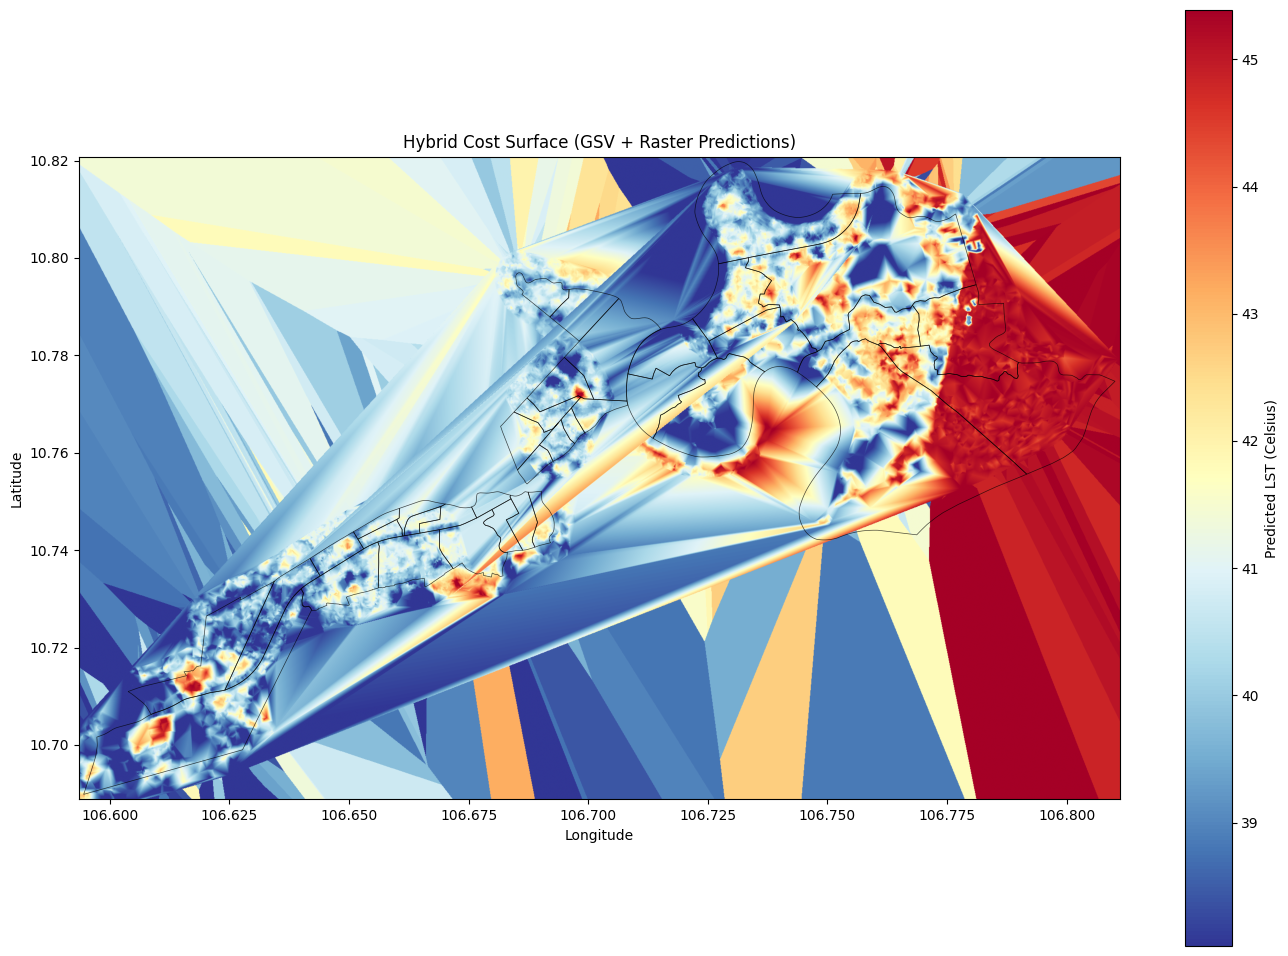

In [26]:
# Visualize hybrid cost surface with study area overlay.
fig, ax = plt.subplots(1, 1, figsize = (14, 12))

# Plot hybrid surface.
im = ax.imshow(
    hybrid_surface,
    extent = [raster_minx, raster_maxx, raster_miny, raster_maxy],
    cmap = "RdYlBu_r",
    vmin = np.nanpercentile(hybrid_surface, 5),
    vmax = np.nanpercentile(hybrid_surface, 95),
    origin = "upper"
)

# Overlay ward boundaries.
gdf_wards.boundary.plot(
    ax = ax,
    color = "black",
    linewidth = 0.5,
    alpha = 0.7
)

# Highlight GSV wards.
if ward_col:
    gsv_wards_gdf = gdf_wards[gdf_wards[ward_col].isin(GSV_WARDS)]
    gsv_wards_gdf.boundary.plot(
        ax = ax,
        color = "green",
        linewidth = 2,
        alpha = 0.9
    )

cbar = plt.colorbar(im, ax = ax, label = "Predicted LST (Celsius)", shrink = 0.8)
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.set_title("Hybrid Cost Surface (GSV + Raster Predictions)")

plt.tight_layout()
plt.show()

## LOAD NETWORK GRAPH

In [27]:
# Load network graph.
if NETWORK_FILE.exists():
    G = ox.load_graphml(NETWORK_FILE)
    print(f"Loaded network from file: {len(G.nodes)} nodes, {len(G.edges)} edges.")
else:
    # Download network if not available.
    print("Network file not found. Downloading from OSM.")
    study_area = gdf_wards.unary_union
    G = ox.graph_from_polygon(study_area, network_type = "walk")
    ox.save_graphml(G, NETWORK_FILE)
    print(f"Downloaded network: {len(G.nodes)} nodes, {len(G.edges)} edges.")

Network file not found. Downloading from OSM.
Downloaded network: 12307 nodes, 33724 edges.


In [28]:
# Convert to undirected graph for routing.
G_undirected = G.to_undirected()

print(f"Undirected graph: {len(G_undirected.nodes)} nodes, {len(G_undirected.edges)} edges.")

Undirected graph: 12307 nodes, 16913 edges.


## ASSIGN HEAT WEIGHTS TO EDGES

In [29]:
# Extract node coordinates.
node_coords = {node: (data["x"], data["y"]) for node, data in G_undirected.nodes(data = True)}

print(f"Extracted coordinates for {len(node_coords)} nodes.")

Extracted coordinates for 12307 nodes.


In [30]:
# Sample LST from hybrid surface for each node.
print("Sampling LST values from hybrid surface for each node.")

node_lst = {}

for node, (lon, lat) in node_coords.items():
    # Convert coordinates to pixel indices.
    col = int((lon - raster_minx) / RESOLUTION)
    row = int((raster_maxy - lat) / RESOLUTION)

    # Check bounds.
    if 0 <= row < height and 0 <= col < width:
        lst_value = hybrid_surface[row, col]
        if not np.isnan(lst_value):
            node_lst[node] = lst_value
        else:
            node_lst[node] = np.nanmean(hybrid_surface)  # Default to mean.
    else:
        node_lst[node] = np.nanmean(hybrid_surface)  # Default to mean.

print(f"Assigned LST values to {len(node_lst)} nodes.")
print(f"LST range: {min(node_lst.values()):.2f} to {max(node_lst.values()):.2f}")

Sampling LST values from hybrid surface for each node.
Assigned LST values to 12307 nodes.
LST range: 35.84 to 46.16


In [31]:
# Assign inverted heat weights to edges.
# Dijkstra finds MINIMUM cost path.
# To find HOTTEST path, invert LST so higher temps have LOWER cost.
print("Assigning inverted heat weights to edges.")

# Get LST range for inversion.
lst_min = min(node_lst.values())
lst_max = max(node_lst.values())

for u, v, data in G_undirected.edges(data = True):
    # Get average LST of edge endpoints.
    lst_u = node_lst.get(u, np.nanmean(hybrid_surface))
    lst_v = node_lst.get(v, np.nanmean(hybrid_surface))
    avg_lst = (lst_u + lst_v) / 2

    # Invert LST: higher temperature = lower cost.
    # Inverted cost = max_LST - actual_LST + small epsilon.
    inverted_cost = lst_max - avg_lst + 0.01

    # Store both original LST and inverted cost.
    data["avg_lst"] = avg_lst
    data["heat_cost"] = inverted_cost

print("Heat weights assigned.")
print(f"Inverted cost range: {lst_max - lst_max + 0.01:.2f} (hottest) to {lst_max - lst_min + 0.01:.2f} (coolest)")

Assigning inverted heat weights to edges.


KeyboardInterrupt: 

## SELECT START AND END POINTS

In [ ]:
# Select start and end points far apart for interesting route.
# Use corners of study area for maximum distance.
print("Selecting start and end points.")

# Find nodes near southwest and northeast corners.
sw_corner = (minx + 0.01, miny + 0.01)
ne_corner = (maxx - 0.01, maxy - 0.01)

# Find nearest nodes to corners.
start_node = ox.nearest_nodes(G_undirected, sw_corner[0], sw_corner[1])
end_node = ox.nearest_nodes(G_undirected, ne_corner[0], ne_corner[1])

start_coords = node_coords[start_node]
end_coords = node_coords[end_node]

print(f"Start node: {start_node} at ({start_coords[0]:.6f}, {start_coords[1]:.6f})")
print(f"End node: {end_node} at ({end_coords[0]:.6f}, {end_coords[1]:.6f})")

# Calculate straight-line distance.
from math import radians, sin, cos, sqrt, atan2

def haversine(lon1, lat1, lon2, lat2):
    R = 6371000  # Earth radius in meters.
    phi1 = radians(lat1)
    phi2 = radians(lat2)
    dphi = radians(lat2 - lat1)
    dlambda = radians(lon2 - lon1)
    a = sin(dphi/2)**2 + cos(phi1) * cos(phi2) * sin(dlambda/2)**2
    c = 2 * atan2(sqrt(a), sqrt(1-a))
    return R * c

distance = haversine(start_coords[0], start_coords[1], end_coords[0], end_coords[1])
print(f"Straight-line distance: {distance:.0f} meters ({distance/1000:.2f} km)")

## RUN DIJKSTRA FOR HOTTEST PATH

In [ ]:
# Run Dijkstra algorithm with inverted heat cost.
print("Running Dijkstra algorithm to find HOTTEST path.")

try:
    hottest_path = nx.dijkstra_path(
        G_undirected,
        start_node,
        end_node,
        weight = "heat_cost"
    )

    hottest_path_length = nx.dijkstra_path_length(
        G_undirected,
        start_node,
        end_node,
        weight = "heat_cost"
    )

    print(f"Hottest path found: {len(hottest_path)} nodes.")
    print(f"Total inverted cost: {hottest_path_length:.2f}")

except nx.NetworkXNoPath:
    print("No path found between start and end nodes.")
    hottest_path = None

In [ ]:
# Calculate path statistics.
if hottest_path:
    path_lsts = []
    path_coords = []

    for node in hottest_path:
        path_lsts.append(node_lst.get(node, np.nan))
        path_coords.append(node_coords[node])

    print("HOTTEST PATH STATISTICS")
    print(f"Number of nodes: {len(hottest_path)}")
    print(f"Average LST along path: {np.nanmean(path_lsts):.2f} C")
    print(f"Max LST along path: {np.nanmax(path_lsts):.2f} C")
    print(f"Min LST along path: {np.nanmin(path_lsts):.2f} C")

    # Calculate path length in meters.
    total_distance = 0
    for i in range(len(path_coords) - 1):
        lon1, lat1 = path_coords[i]
        lon2, lat2 = path_coords[i + 1]
        total_distance += haversine(lon1, lat1, lon2, lat2)

    print(f"Total path length: {total_distance:.0f} meters ({total_distance/1000:.2f} km)")

## VISUALIZE HOTTEST ROUTE

In [ ]:
# Create visualization of hottest route over hybrid LST surface.
fig, ax = plt.subplots(1, 1, figsize = (16, 14))

# Plot hybrid surface.
im = ax.imshow(
    hybrid_surface,
    extent = [raster_minx, raster_maxx, raster_miny, raster_maxy],
    cmap = "RdYlBu_r",
    vmin = np.nanpercentile(hybrid_surface, 5),
    vmax = np.nanpercentile(hybrid_surface, 95),
    origin = "upper",
    alpha = 0.8
)

# Overlay ward boundaries.
gdf_wards.boundary.plot(
    ax = ax,
    color = "gray",
    linewidth = 0.5,
    alpha = 0.5
)

# Plot hottest path.
if hottest_path:
    path_x = [node_coords[n][0] for n in hottest_path]
    path_y = [node_coords[n][1] for n in hottest_path]

    ax.plot(
        path_x,
        path_y,
        color = "magenta",
        linewidth = 3,
        label = "Hottest Route",
        zorder = 10
    )

    # Mark start and end.
    ax.scatter(
        [start_coords[0]],
        [start_coords[1]],
        c = "lime",
        s = 200,
        marker = "o",
        edgecolor = "black",
        linewidth = 2,
        label = "Start",
        zorder = 11
    )

    ax.scatter(
        [end_coords[0]],
        [end_coords[1]],
        c = "red",
        s = 200,
        marker = "X",
        edgecolor = "black",
        linewidth = 2,
        label = "End",
        zorder = 11
    )

cbar = plt.colorbar(im, ax = ax, label = "Predicted LST (Celsius)", shrink = 0.7)
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.set_title("HOTTEST Route (Hybrid Patchwork Approach)\nDijkstra with Inverted Heat Cost")
ax.legend(loc = "upper right")

plt.tight_layout()
plt.show()

## SAVE HOTTEST ROUTE

In [ ]:
# Save hottest route as GeoJSON.
if hottest_path:
    # Create LineString geometry.
    route_line = LineString(path_coords)

    # Create GeoDataFrame.
    gdf_route = gpd.GeoDataFrame(
        {
            "route_type": ["hottest_hybrid"],
            "num_nodes": [len(hottest_path)],
            "avg_lst": [np.nanmean(path_lsts)],
            "max_lst": [np.nanmax(path_lsts)],
            "min_lst": [np.nanmin(path_lsts)],
            "length_m": [total_distance],
        },
        geometry = [route_line],
        crs = "EPSG:4326"
    )

    # Save to file.
    gdf_route.to_file(HOTTEST_ROUTE, driver = "GeoJSON")

    print(f"Hottest route saved to {HOTTEST_ROUTE}")
    print(gdf_route)

## SUMMARY

In [ ]:
print("HYBRID PATCHWORK DIJKSTRA SUMMARY")
print("")
print("Approach: Merge GSV predictions (high fidelity) with raster-only predictions (full coverage).")
print("")
print("OUTPUTS")
print(f"Raster-only predictions: {PRED_RASTER_ONLY}")
print(f"GSV predictions (masked): {PRED_GSV}")
print(f"Hybrid cost surface: {HYBRID_RASTER}")
print(f"Hottest route: {HOTTEST_ROUTE}")
print("")
if hottest_path:
    print("ROUTE STATISTICS")
    print(f"Path length: {total_distance/1000:.2f} km")
    print(f"Average LST: {np.nanmean(path_lsts):.2f} C")
    print(f"Max LST: {np.nanmax(path_lsts):.2f} C")